In [ ]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("mydrone_Data.csv")

In [3]:
df.head()

,time(millisecond),datetime(utc),latitude,longitude,height_above_takeoff(feet),height_above_ground_at_drone_location(feet),ground_elevation_at_drone_location(feet),altitude_above_seaLevel(feet),height_sonar(feet),speed(mph),...,voltageCell4,voltageCell5,voltageCell6,current(A),battery_temperature(f),altitude(feet),ascent(feet),flycStateRaw,flycState,message
0,5510,3/16/2022 18:39,36.559037,-89.074368,29.855644,29.855644,367.743461,397.599105,0,0.000000,...,NaN,NaN,NaN,15.88,29.950016,397.599105,29.855644,14,Waypoint,NaN
1,5610,3/16/2022 18:39,36.559037,-89.074368,30.839896,30.839896,367.743461,398.583357,0,0.000000,...,NaN,NaN,NaN,15.88,29.950016,398.583357,30.839896,14,Waypoint,Mission did take off
2,5710,3/16/2022 18:39,36.559037,-89.074368,31.824148,31.824148,367.743461,399.567609,0,0.000000,...,NaN,NaN,NaN,15.88,29.950016,399.567609,31.824148,14,Waypoint,NaN
3,5810,3/16/2022 18:39,36.559037,-89.074367,32.808400,32.808400,367.743461,400.551861,0,0.000000,...,NaN,NaN,NaN,15.88,29.950016,400.551861,32.808400,14,Waypoint,NaN
4,5910,3/16/2022 18:39,36.559037,-89.074367,33.792652,33.792652,367.743461,401.536113,0,0.223694,...,NaN,NaN,NaN,15.88,29.950016,401.536113,33.792652,14,Waypoint,NaN


In [18]:
df_clean = df.drop(columns=["message", 
                            'voltageCell1',
                            'voltageCell2',
                            'voltageCell3', 
                            'voltageCell4', 
                            'voltageCell5',
                            'time(millisecond)', 
                            'datetime(utc)',
       'voltageCell6'])

In [19]:
df_clean.columns

Index(['latitude', 'longitude', 'height_above_takeoff(feet)',
       'height_above_ground_at_drone_location(feet)',
       'ground_elevation_at_drone_location(feet)',
       'altitude_above_seaLevel(feet)', 'height_sonar(feet)', 'speed(mph)',
       'distance(feet)', 'mileage(feet)', 'satellites', 'gpslevel',
       'voltage(v)', 'max_altitude(feet)', 'max_ascent(feet)',
       'max_speed(mph)', 'max_distance(feet)', ' xSpeed(mph)', ' ySpeed(mph)',
       ' zSpeed(mph)', ' compass_heading(degrees)', ' pitch(degrees)',
       ' roll(degrees)', 'isPhoto', 'isVideo', 'rc_elevator', 'rc_aileron',
       'rc_throttle', 'rc_rudder', 'rc_elevator(percent)',
       'rc_aileron(percent)', 'rc_throttle(percent)', 'rc_rudder(percent)',
       'gimbal_heading(degrees)', 'gimbal_pitch(degrees)',
       'gimbal_roll(degrees)', 'battery_percent', 'current(A)',
       'battery_temperature(f)', 'altitude(feet)', 'ascent(feet)',
       'flycStateRaw', 'flycState'],
      dtype='str')

In [20]:
df_clean.head()

,latitude,longitude,height_above_takeoff(feet),height_above_ground_at_drone_location(feet),ground_elevation_at_drone_location(feet),altitude_above_seaLevel(feet),height_sonar(feet),speed(mph),distance(feet),mileage(feet),...,gimbal_heading(degrees),gimbal_pitch(degrees),gimbal_roll(degrees),battery_percent,current(A),battery_temperature(f),altitude(feet),ascent(feet),flycStateRaw,flycState
0,36.559037,-89.074368,29.855644,29.855644,367.743461,397.599105,0,0.000000,0.000000,0.000000,...,254.4,-90.0,0,93,15.88,29.950016,397.599105,29.855644,14,Waypoint
1,36.559037,-89.074368,30.839896,30.839896,367.743461,398.583357,0,0.000000,0.047036,0.047036,...,254.4,-90.0,0,93,15.88,29.950016,398.583357,30.839896,14,Waypoint
2,36.559037,-89.074368,31.824148,31.824148,367.743461,399.567609,0,0.000000,0.095541,0.096559,...,254.4,-90.0,0,93,15.88,29.950016,399.567609,31.824148,14,Waypoint
3,36.559037,-89.074367,32.808400,32.808400,367.743461,400.551861,0,0.000000,0.139809,0.141238,...,254.4,-90.0,0,93,15.88,29.950016,400.551861,32.808400,14,Waypoint
4,36.559037,-89.074367,33.792652,33.792652,367.743461,401.536113,0,0.223694,0.174553,0.176650,...,254.4,-89.9,0,93,15.88,29.950016,401.536113,33.792652,14,Waypoint


In [ ]:
selected_cols = [
       'height_above_takeoff(feet)',
       'height_above_ground_at_drone_location(feet)',
       'ground_elevation_at_drone_location(feet)',
       'altitude_above_seaLevel(feet)', 'height_sonar(feet)', 'speed(mph)',
       'distance(feet)', 'mileage(feet)', 'satellites', 'gpslevel',
       'voltage(v)', 'max_altitude(feet)', 'max_ascent(feet)',
       'max_speed(mph)', 'max_distance(feet)', ' xSpeed(mph)', ' ySpeed(mph)',
       ' zSpeed(mph)', ' compass_heading(degrees)', ' pitch(degrees)',
       ' roll(degrees)', 'isPhoto', 'isVideo', 'rc_elevator', 'rc_aileron',
       'rc_throttle', 'rc_rudder', 'rc_elevator(percent)',
       'rc_aileron(percent)', 'rc_throttle(percent)', 'rc_rudder(percent)',
       'gimbal_heading(degrees)', 'gimbal_pitch(degrees)',
       'gimbal_roll(degrees)', 'battery_percent', 'voltageCell1',
       'voltageCell2', 'voltageCell3', 'voltageCell4', 'voltageCell5',
       'voltageCell6', 'current(A)', 'battery_temperature(f)',
       'altitude(feet)', 'ascent(feet)', 'flycStateRaw', 'flycState']
      

In [55]:
df_clean.dropna(inplace=True)
df_clean = df_clean[df["flycState"].isin(['Waypoint', 'AutoLanding', 'Sport'])]

In [56]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

In [57]:
df_clean["flycState"].value_counts()

flycState
Waypoint       7387
AutoLanding     546
Sport           193
Name: count, dtype: int64

In [59]:
encode = LabelEncoder()

X = df_clean.drop(columns=["flycState"])
y = encode.fit_transform(df_clean["flycState"])

print(X.shape)
print(len(y))

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                    random_state=42, 
                                                    stratify=y)

(8126, 42)
8126


In [60]:
print(y)

[2 2 2 ... 1 1 1]


In [61]:
list(dict.fromkeys(y))

[np.int64(2), np.int64(0), np.int64(1)]

In [64]:
pipe = Pipeline([("preprocess",StandardScaler()),
                ("model", XGBClassifier())])

model = pipe.fit(X_train,y_train)

In [77]:
import joblib

joblib.dump(model, "classify.joblib")


['classify.joblib']

In [ ]:
# # 2. Save the model to a file
# joblib.dump(model, 'mymodel.joblib')

# # 3. Load the model back later
# loaded_model = joblib.load('mymodel.joblib')

# # 4. Use the loaded model for predictions
# predictions = loaded_model.predict(data.data[:2])
# print(predictions)

In [73]:
y_predict = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00        39
           2       1.00      1.00      1.00      1478

    accuracy                           1.00      1626
   macro avg       1.00      1.00      1.00      1626
weighted avg       1.00      1.00      1.00      1626



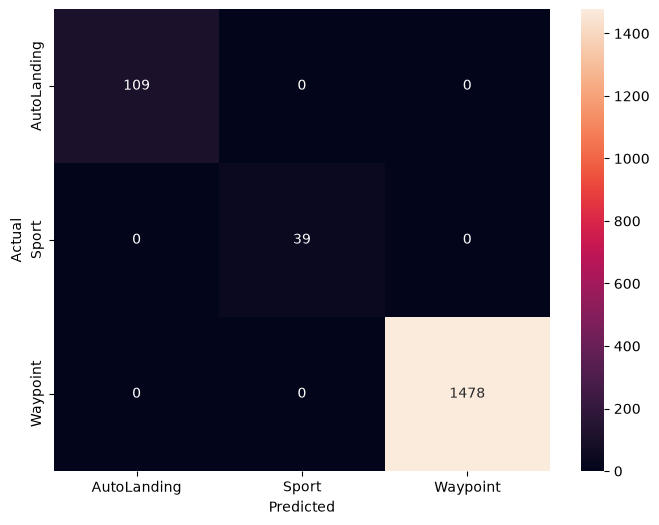

In [78]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_predict)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=encode.classes_,
    yticklabels=encode.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

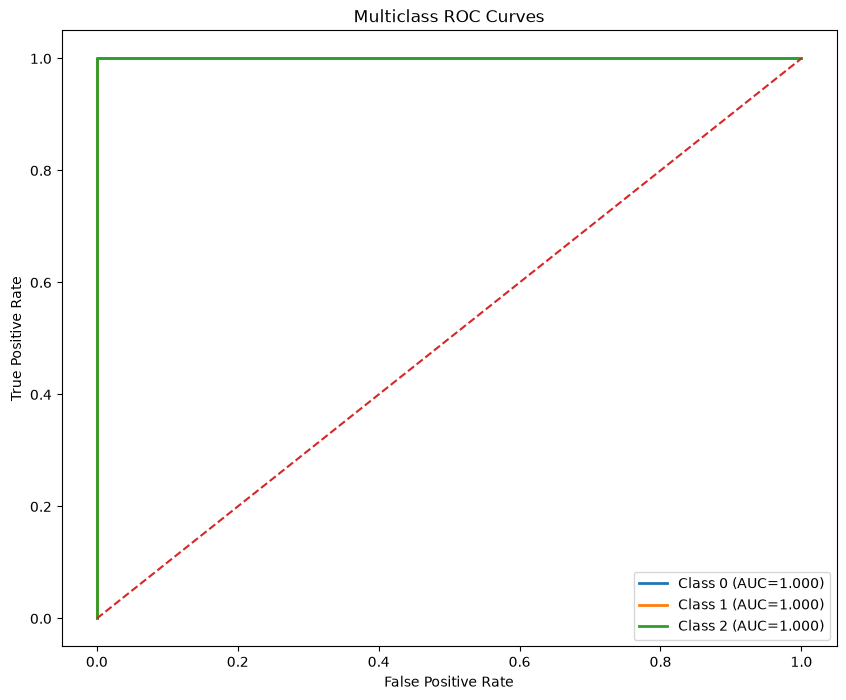

In [76]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(y_test)

y_test_bin = label_binarize(y_test, classes=classes)

y_prob = model.predict_proba(X_test)

plt.figure(figsize=(10, 8))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"Class {classes[i]} (AUC={roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")
plt.legend(loc="lower right")
plt.show()